## 0. Chuẩn bị thư viện và đường dẫn

In [1]:
from pathlib import Path
import json
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_CSV = ROOT / "data" / "dataset" / "data.csv"
ENRICHED_JSON = ROOT / "data" / "dataset" / "data_enriched.json"
CHUNKS_JSON = ROOT / "data" / "chunks" / "chunks.json"
QA_JSON = ROOT / "data" / "eval" / "generated_qa_30.json"
CONFIG_YAML = ROOT / "configs" / "benchmark_models.yaml"
VECTOR_DIR = ROOT / "data" / "vector_store"
RETRIEVAL_DIR = ROOT / "results" / "retrieval_benchmark"
RAG_DIR = ROOT / "results" / "rag_benchmark"
EVAL_DIR = ROOT / "results" / "generated_qa_30"

print("ROOT:", ROOT)
print("Dữ liệu đã làm giàu:", ENRICHED_JSON.relative_to(ROOT))

ROOT: /Users/quangnguyentamhuu/Desktop/Chatbox_ChatBox_BanThuocTruSauNongNghiep
Dữ liệu đã làm giàu: data/dataset/data_enriched.json


## 1.1. Tải, khảo sát và phân tích dữ liệu văn bản

Dữ liệu chính của project là tập sản phẩm thuốc nông nghiệp đã được làm giàu tại `data/dataset/data_enriched.json`. Mỗi dòng tương ứng với một sản phẩm, gồm các trường văn bản như tên sản phẩm, công dụng, triệu chứng, hướng dẫn sử dụng, lưu ý an toàn và các trường suy luận hỗ trợ truy xuất.

In [2]:
products = json.loads(ENRICHED_JSON.read_text(encoding="utf-8"))
chunks = json.loads(CHUNKS_JSON.read_text(encoding="utf-8"))
qa_items = json.loads(QA_JSON.read_text(encoding="utf-8"))

df = pd.DataFrame(products)
chunks_df = pd.DataFrame(chunks)
qa_df = pd.DataFrame(qa_items)

overview = pd.DataFrame([
    {"Thành phần": "Sản phẩm sau làm giàu", "Số lượng": len(df)},
    {"Thành phần": "Số trường dữ liệu", "Số lượng": len(df.columns)},
    {"Thành phần": "Chunks phục vụ embedding", "Số lượng": len(chunks_df)},
    {"Thành phần": "Câu hỏi đánh giá generated_qa_30", "Số lượng": len(qa_df)},
])
display(overview)
display(df.head())

,Thành phần,Số lượng
0,Sản phẩm sau làm giàu,500
1,Số trường dữ liệu,20
2,Chunks phục vụ embedding,1000
3,Câu hỏi đánh giá generated_qa_30,30


,product_id,ten_san_pham,loai,thanh_phan,quy_cach,cong_dung,trieu_chung,nguyen_nhan,doi_tuong_cay_trong,thoi_diem_xu_ly,huong_dan_su_dung,an_toan_su_dung,gia,url_img,rule_key,dac_tinh_benh,giai_doan_phu_hop,loai_dat_moi_truong,goi_y_phoi_hop,ly_do_chuyen_gia
0,sp1,KẼM BORON 50.000ppm,phan_bon,"{'kem_zn': '50.000ppm', 'bo_b': '50.000ppm', '...",Gói 500g,"[Tăng khả năng thụ phấn, đậu trái, hạn chế rụn...","[Hoa khô, rụng hàng loạt, trái non dễ rụng, lá...",[Thiếu vi lượng Kẽm và Bo trong giai đoạn phân...,"[Cây ăn trái, cà phê, hồ tiêu, lúa, rau màu]","[Trước ra hoa, sau đậu trái, giai đoạn nuôi tr...",{'cach_dung': 'Pha 500g cho phuy 200-250 lít n...,"[Không pha chung với thuốc có tính kiềm mạnh, ...","{'tu': 75000, 'den': 90000, 'don_vi': 'VND'}",IMG/sp1,"phan_bon | Hoa khô, rụng hàng loạt; trái non d...",[Bổ sung dinh dưỡng thiếu hụt cho cây],"[Trước ra hoa, Sau đậu trái, Nuôi trái, củ hoặ...","[Đất thiếu vi lượng, Đất canh tác lâu năm, dễ ...","[Chất bám dính sinh học, Phân bón lá Amino Aci...",KẼM BORON 50.000ppm phù hợp vì sản phẩm tập tr...
1,sp2,NPK 20-20-15 TE,phan_bon,"{'dam_n': '20%', 'lan_p2o5': '20%', 'kali_k2o'...",Bao 25kg,"[Cung cấp dinh dưỡng cân đối, giúp cây phát tr...","[Cây sinh trưởng chậm, lá nhạt màu, đậu trái kém]",[Đất thiếu đa lượng NPK hoặc bón phân mất cân ...,"[Lúa, bắp, rau màu, cây ăn trái, cây công nghiệp]","[Giai đoạn sinh trưởng mạnh, sau thu hoạch, tr...",{'cach_dung': 'Bón gốc 200-500kg/ha tùy cây tr...,"[Không bón sát gốc, tưới nước sau khi bón để t...","{'tu': 520000, 'den': 650000, 'don_vi': 'VND/b...",IMG/sp2,"phan_bon | Cây sinh trưởng chậm, lá nhạt màu, ...",[Bổ sung dinh dưỡng thiếu hụt cho cây],"[Cây con, Giai đoạn sinh trưởng mạnh, Trước ra...","[Đất thiếu vi lượng, Đất cần bổ sung Kali cho ...","[Chất bám dính sinh học, Phân bón lá Amino Aci...",NPK 20-20-15 TE phù hợp vì sản phẩm tập trung ...
2,sp3,DAP 18-46-0,phan_bon,"{'dam_n': '18%', 'lan_huu_hieu_p2o5': '46%'}",Bao 50kg,"[Kích thích ra rễ, phục hồi cây con, tăng sức ...","[Rễ yếu, cây còi, chậm bén rễ sau trồng]",[Thiếu lân trong giai đoạn đầu hoặc đất chua l...,"[Lúa, rau màu, cây ăn trái, cà phê, hồ tiêu]","[Bón lót, bón thúc sớm sau trồng]",{'cach_dung': 'Bón 100-300kg/ha; cây ăn trái b...,"[Tránh trộn trực tiếp với vôi, bảo quản khô, t...","{'tu': 1100000, 'den': 1350000, 'don_vi': 'VND...",IMG/sp3,"phan_bon | Rễ yếu, cây còi, chậm bén rễ sau trồng","[Bổ sung dinh dưỡng thiếu hụt cho cây, Giúp câ...","[Cây con, Sau thu hoạch, phục hồi cây]",[Đất phèn hoặc đất chua],"[Chất bám dính sinh học, Phân bón lá Amino Aci...",DAP 18-46-0 phù hợp vì sản phẩm tập trung xử l...
3,sp4,KALI CLORUA KCl 60%,phan_bon,"{'kali_huu_hieu_k2o': '60%', 'dang_kcl': 'dạng...",Bao 50kg,"[Tăng độ ngọt, chắc hạt, cứng cây, tăng khả nă...","[Trái nhạt, mềm, lá mép vàng cháy, cây yếu dễ ...","[Thiếu Kali hoặc cây đang nuôi trái, nuôi củ c...","[Lúa, mía, chuối, cây ăn trái, khoai, sắn]","[Giai đoạn làm đòng, nuôi trái, nuôi củ]",{'cach_dung': 'Bón 100-250kg/ha; cây ăn trái 0...,"[Không bón quá liều trên cây mẫn cảm Clo, trán...","{'tu': 750000, 'den': 950000, 'don_vi': 'VND/b...",IMG/sp4,"phan_bon | Trái nhạt, mềm; lá mép vàng cháy; c...",[Bổ sung dinh dưỡng thiếu hụt cho cây],"[Nuôi trái, củ hoặc hạt]",[Đất cần bổ sung Kali cho giai đoạn nuôi trái],"[Chất bám dính sinh học, Phân bón lá Amino Aci...",KALI CLORUA KCl 60% phù hợp vì sản phẩm tập tr...
4,sp5,CANXI BO MAX,phan_bon,"{'cao': '15%', 'bo_b': '2%', 'mgo': '2%', 'phu...",Chai 1 lít,"[Chống nứt trái, thối đít trái, tăng cứng vỏ v...","[Trái cà chua thối đáy, sầu riêng nứt gai, ớt ...","[Thiếu Canxi và Bo, rối loạn vận chuyển dinh d...","[Cà chua, ớt, dưa leo, sầu riêng, xoài, cam quýt]","[Trước ra hoa, sau đậu trái, giai đoạn trái lớ...",{'cach_dung': 'Pha 25-40ml/bình 16 lít; phun 7...,"[Không pha với phân chứa phosphate đậm đặc, lắ...","{'tu': 95000, 'den': 140000, 'don_vi': 'VND'}",IMG/sp5,phan_bon | Trái cà chua thối đáy; sầu riêng nứ...,[Bổ sung dinh dưỡng thiếu hụt cho cây],"[Trước ra hoa, S

## 1.2. Khảo sát nhãn dữ liệu

Trong project này, nhãn dữ liệu chính là trường `loai`, biểu diễn nhóm sản phẩm như phân bón, thuốc trừ sâu, thuốc trừ bệnh, thuốc trừ cỏ và thuốc kích thích sinh trưởng.

,loai,so_luong
0,phan_bon,167
1,thuoc_tru_benh,117
2,thuoc_tru_sau,111
3,thuoc_tru_co,54
4,thuoc_kich_thich_sinh_truong,51


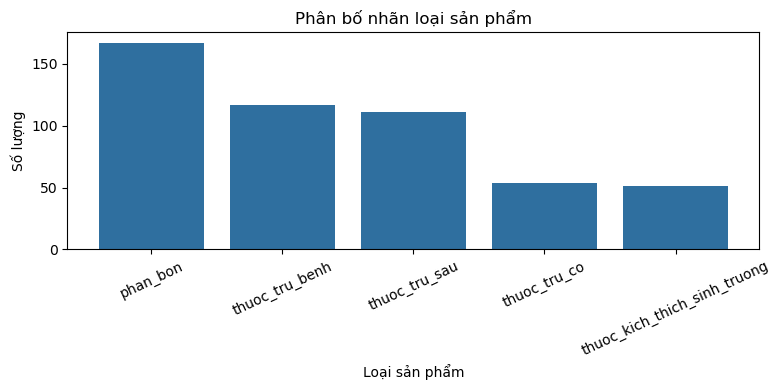

In [3]:
label_counts = df["loai"].value_counts().rename_axis("loai").reset_index(name="so_luong")
display(label_counts)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(label_counts["loai"], label_counts["so_luong"], color="#2f6f9f")
ax.set_title("Phân bố nhãn loại sản phẩm")
ax.set_xlabel("Loại sản phẩm")
ax.set_ylabel("Số lượng")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 1.3. Phân tích độ dài văn bản

Đối với bài toán NLP, độ dài văn bản ảnh hưởng trực tiếp đến quá trình tokenization, chunking và giới hạn context của mô hình. Ở đây, ta ghép các trường văn bản quan trọng thành một đoạn mô tả sản phẩm để khảo sát độ dài.

,ten_san_pham,loai,word_count
0,KẼM BORON 50.000ppm,phan_bon,223
1,NPK 20-20-15 TE,phan_bon,237
2,DAP 18-46-0,phan_bon,192
3,KALI CLORUA KCl 60%,phan_bon,188
4,CANXI BO MAX,phan_bon,220


,word_count
count,500.00000
mean,207.79400
std,23.10314
min,153.00000
25%,190.00000
50%,207.00000
75%,224.00000
max,270.00000


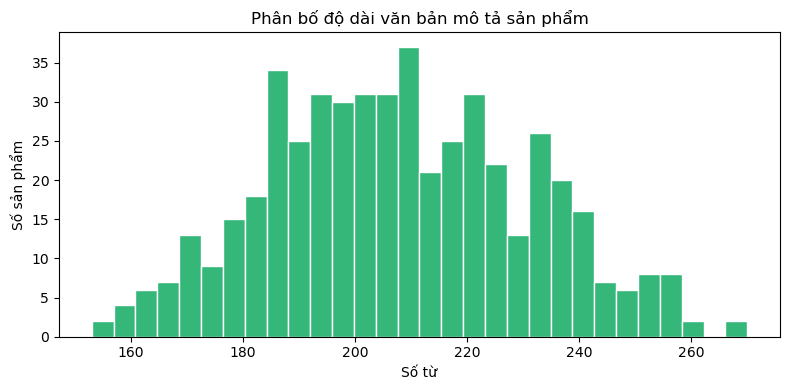

In [4]:
text_fields = [
    "ten_san_pham", "loai", "thanh_phan", "cong_dung", "trieu_chung", "nguyen_nhan",
    "doi_tuong_cay_trong", "thoi_diem_xu_ly", "huong_dan_su_dung", "an_toan_su_dung",
    "dac_tinh_benh", "giai_doan_phu_hop", "loai_dat_moi_truong", "goi_y_phoi_hop", "ly_do_chuyen_gia",
]

def join_text(row):
    values = []
    for field in text_fields:
        value = row.get(field, "")
        if isinstance(value, list):
            value = ", ".join(map(str, value))
        elif isinstance(value, dict):
            value = "; ".join(f"{k}: {v}" for k, v in value.items())
        if value:
            values.append(str(value))
    return " ".join(values)

df["full_text"] = df.apply(join_text, axis=1)
df["word_count"] = df["full_text"].str.split().str.len()

display(df[["ten_san_pham", "loai", "word_count"]].head())
display(df["word_count"].describe().to_frame("word_count"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["word_count"], bins=30, color="#35b779", edgecolor="white")
ax.set_title("Phân bố độ dài văn bản mô tả sản phẩm")
ax.set_xlabel("Số từ")
ax.set_ylabel("Số sản phẩm")
plt.tight_layout()
plt.show()

## 1.4. Phân bố từ vựng

Biểu đồ dưới đây minh họa các từ xuất hiện nhiều trong dữ liệu sau khi ghép các trường văn bản. Đây là bước khảo sát cơ bản để hiểu chủ đề chính của corpus.

,tu,tan_suat
0,sau,1767
1,trái,1457
2,đất,1384
3,sinh,1180
4,thiếu,1077
5,lít,986
6,bệnh,933
7,phân,865
8,bón,860
9,hợp,838


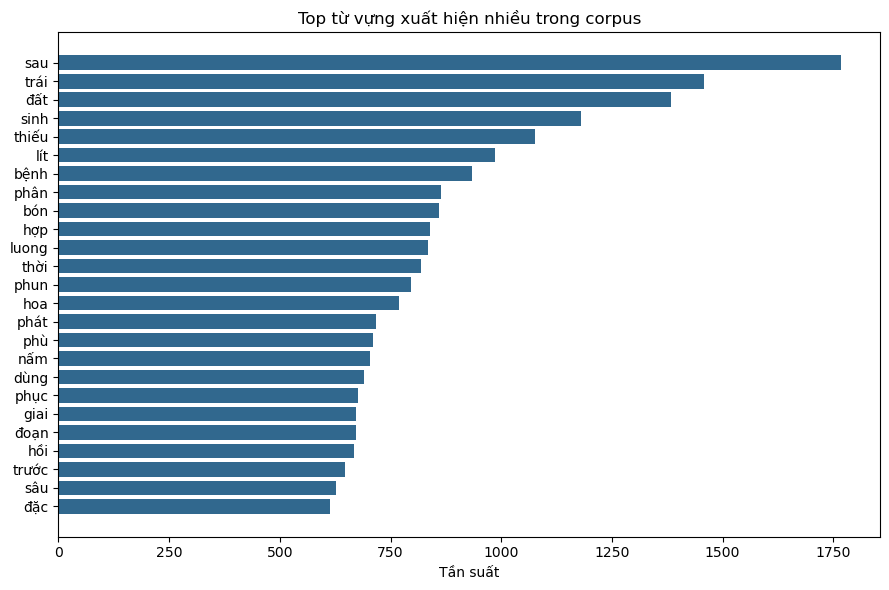

In [5]:
stopwords = {
    "và", "của", "cho", "các", "khi", "với", "trong", "hoặc", "theo", "là", "có", "để", "nên",
    "sử", "dụng", "sản", "phẩm", "cây", "trồng", "bị", "giúp", "tăng", "hỗ", "trợ",
}

tokens = re.findall(r"[a-zA-ZÀ-ỹ0-9]+", " ".join(df["full_text"]).lower())
tokens = [t for t in tokens if len(t) >= 3 and t not in stopwords]
token_counts = Counter(tokens)
top_words = pd.DataFrame(token_counts.most_common(25), columns=["tu", "tan_suat"])
display(top_words)

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = top_words.sort_values("tan_suat")
ax.barh(plot_df["tu"], plot_df["tan_suat"], color="#31688e")
ax.set_title("Top từ vựng xuất hiện nhiều trong corpus")
ax.set_xlabel("Tần suất")
plt.tight_layout()
plt.show()

## 1.5. Tiền xử lý, xử lý mất cân bằng và làm giàu dữ liệu

Trong project, dữ liệu được tiền xử lý bằng script `scripts/lam_giau_du_lieu.py`. Các bước chính gồm làm sạch văn bản, chuẩn hóa trường, sửa lỗi tiếng Việt, phân tích giá/thành phần/hướng dẫn sử dụng và sinh thêm các trường suy luận để giúp mô hình dễ truy xuất hơn.

In [6]:
enriched_fields = [
    "rule_key", "dac_tinh_benh", "giai_doan_phu_hop", "loai_dat_moi_truong", "goi_y_phoi_hop", "ly_do_chuyen_gia"
]
sample_cols = ["ten_san_pham", "loai", "cong_dung", "trieu_chung"] + enriched_fields
display(df[sample_cols].head(3).T)

missing = df[sample_cols].isna().sum().reset_index()
missing.columns = ["truong", "so_gia_tri_thieu"]
display(missing)

,0,1,2
ten_san_pham,KẼM BORON 50.000ppm,NPK 20-20-15 TE,DAP 18-46-0
loai,phan_bon,phan_bon,phan_bon
cong_dung,"[Tăng khả năng thụ phấn, đậu trái, hạn chế rụn...","[Cung cấp dinh dưỡng cân đối, giúp cây phát tr...","[Kích thích ra rễ, phục hồi cây con, tăng sức ..."
trieu_chung,"[Hoa khô, rụng hàng loạt, trái non dễ rụng, lá...","[Cây sinh trưởng chậm, lá nhạt màu, đậu trái kém]","[Rễ yếu, cây còi, chậm bén rễ sau trồng]"
rule_key,"phan_bon | Hoa khô, rụng hàng loạt; trái non d...","phan_bon | Cây sinh trưởng chậm, lá nhạt màu, ...","phan_bon | Rễ yếu, cây còi, chậm bén rễ sau trồng"
dac_tinh_benh,[Bổ sung dinh dưỡng thiếu hụt cho cây],[Bổ sung dinh dưỡng thiếu hụt cho cây],"[Bổ sung dinh dưỡng thiếu hụt cho cây, Giúp câ..."
giai_doan_phu_hop,"[Trước ra hoa, Sau đậu trái, Nuôi trái, củ hoặ...","[Cây con, Giai đoạn sinh trưởng mạnh, Trước ra...","[Cây con, Sau thu hoạch, phục hồi cây]"
loai_dat_moi_truong,"[Đất thiếu vi lượng, Đất canh tác lâu năm, dễ ...","[Đất thiếu vi lượng, Đất cần bổ sung Kali cho ...",[Đất phèn hoặc đất chua]
goi_y_phoi_hop,"[Chất bám dính sinh học, Phân bón lá Amino Aci...","[Chất bám dính sinh học, Phân bón lá Amino Aci...","[Chất bám dính sinh học, Phân bón lá Amino Aci..."
ly_do_chuyen_gia,KẼM BORON 50.000ppm phù hợp vì sản phẩm tập tr...,NPK 20-20-15 TE phù hợp vì sản phẩm tập trung ...,DAP 18-46-0 phù hợp vì sản phẩm tập trung xử l...


,truong,so_gia_tri_thieu
0,ten_san_pham,0
1,loai,0
2,cong_dung,0
3,trieu_chung,0
4,rule_key,0
5,dac_tinh_benh,0
6,giai_doan_phu_hop,0
7,loai_dat_moi_truong,0
8,goi_y_phoi_hop,0
9,ly_do_chuyen_gia,0


**Nhận xét cho Câu 1:**

- Dữ liệu sau xử lý có cấu trúc rõ ràng hơn dữ liệu thô.
- Trường `loai` được xem như nhãn dữ liệu để khảo sát mất cân bằng.
- Các trường suy luận như `rule_key`, `dac_tinh_benh`, `giai_doan_phu_hop`, `loai_dat_moi_truong`, `goi_y_phoi_hop`, `ly_do_chuyen_gia` giúp làm giàu ngữ cảnh.
- Việc làm giàu dữ liệu giúp embedding model dễ truy xuất đúng hơn khi người dùng hỏi bằng ngôn ngữ tự nhiên.

## 2.1. Kiến trúc mô hình được sử dụng

Project không fine-tune LLM trực tiếp mà sử dụng hướng **Retrieval-Augmented Generation (RAG)**. Đây là cách phù hợp với dữ liệu sản phẩm vì khi dữ liệu thay đổi, hệ thống chỉ cần cập nhật cơ sở tri thức và vector database, không cần huấn luyện lại toàn bộ LLM.

Luồng xử lý chính:

```text
Câu hỏi người dùng
-> Embedding câu hỏi
-> Truy xuất top-k chunks trong Qdrant
-> Tạo prompt gồm instruction + context + question
-> LLM sinh câu trả lời
-> Redis lưu lịch sử hội thoại nếu chạy chatbot nhiều lượt
```

## 2.2. Embedding model, tokenizer và siêu tham số

Các mô hình embedding được cấu hình trong `configs/benchmark_models.yaml`. Mỗi model có collection riêng trong Qdrant để so sánh công bằng.

In [7]:
try:
    import yaml
except ImportError as exc:
    raise SystemExit("Cần cài PyYAML để đọc configs/benchmark_models.yaml") from exc

config = yaml.safe_load(CONFIG_YAML.read_text(encoding="utf-8"))
models_df = pd.DataFrame(config["models"])
display(models_df)

,alias,model_name,collection_name,batch_size,max_length
0,sup-simcse-vietnamese-phobert-base,VoVanPhuc/sup-SimCSE-VietNamese-phobert-base,thuoc_metadata_sup_simcse,8,256
1,vietnamese-bi-encoder,bkai-foundation-models/vietnamese-bi-encoder,thuoc_metadata_vietnamese_bi_encoder,16,256
2,bge-m3,BAAI/bge-m3,thuoc_metadata_bge_m3,16,8192
3,multilingual-e5-base,intfloat/multilingual-e5-base,thuoc_metadata_multilingual_e5_base,16,512


## 2.3. Kiểm tra vector đã tạo

Các vector đã được xuất từ Qdrant ra `data/vector_store/*.jsonl` để phục vụ kiểm tra và báo cáo. Mỗi file tương ứng một embedding model.

In [8]:
vector_rows = []
for path in sorted(VECTOR_DIR.glob("*.jsonl")):
    line_count = 0
    first = None
    with path.open("r", encoding="utf-8") as f:
        for line_count, line in enumerate(f, start=1):
            if first is None:
                first = json.loads(line)
    vector_rows.append({
        "file": path.name,
        "so_vector": line_count,
        "kich_thuoc_vector": len(first.get("vector", [])) if first else 0,
        "dung_luong_MB": round(path.stat().st_size / (1024 * 1024), 2),
    })

vectors_df = pd.DataFrame(vector_rows)
display(vectors_df)

,file,so_vector,kich_thuoc_vector,dung_luong_MB
0,embeddings_baai__bge_m3.jsonl,1000,1024,23.03
1,embeddings_multilingual_e5_base.jsonl,1000,768,17.52
2,embeddings_sup_simcse_vietnamese_phobert_base....,1000,768,17.53
3,embeddings_vietnamese_bi_encoder.jsonl,1000,768,17.54


## 2.4. LLM và chiến lược transfer learning

Project sử dụng các mô hình tiền huấn luyện thay vì huấn luyện từ đầu. Đây là một dạng ứng dụng transfer learning trong NLP. Hai LLM được dùng để benchmark gồm:

- `Qwen/Qwen2.5-3B-Instruct`
- `Qwen/Qwen3-4B-Instruct-2507`

LLM không được fine-tune lại. Thay vào đó, hệ thống dùng prompt engineering và RAG để cung cấp context từ dữ liệu riêng. Cách này tiết kiệm tài nguyên, dễ cập nhật dữ liệu và phù hợp với bài toán tư vấn sản phẩm.

## 2.5. Đánh giá retrieval-only

Bước này đánh giá riêng embedding model và Qdrant, chưa gọi LLM.

,embedding,so_cau,latency_tb_s,top1_score_tb
1,multilingual_e5_base,18,0.015539,0.871443
2,sup_simcse,18,0.027661,0.779249
0,bge_m3,18,0.025444,0.700680
3,vietnamese_bi_encoder,18,0.015583,0.476994


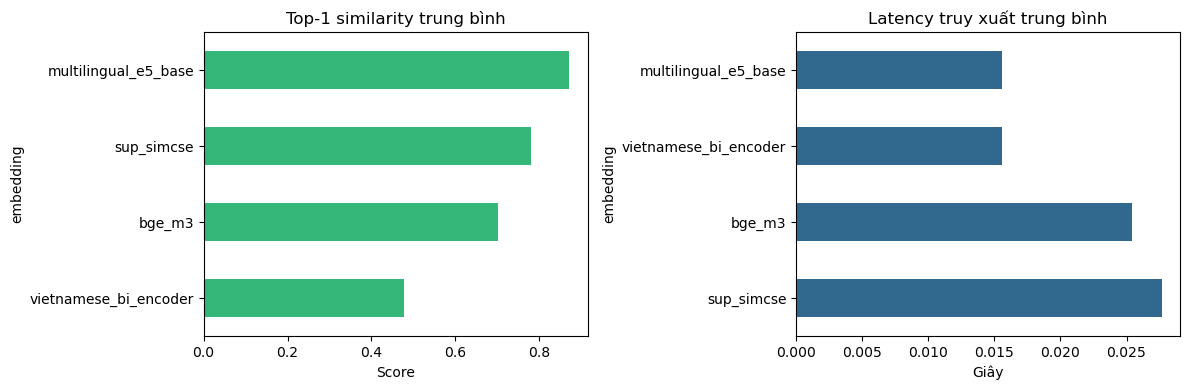

In [9]:
retrieval_rows = []
for path in sorted(RETRIEVAL_DIR.glob("*.json")):
    items = json.loads(path.read_text(encoding="utf-8"))
    latencies = []
    top1_scores = []
    for item in items:
        if isinstance(item.get("latency_seconds"), (int, float)):
            latencies.append(item["latency_seconds"])
        retrieved = item.get("retrieved_chunks", [])
        if retrieved and isinstance(retrieved[0].get("score"), (int, float)):
            top1_scores.append(retrieved[0]["score"])

    retrieval_rows.append({
        "embedding": path.stem,
        "so_cau": len(items),
        "latency_tb_s": sum(latencies) / len(latencies) if latencies else None,
        "top1_score_tb": sum(top1_scores) / len(top1_scores) if top1_scores else None,
    })

retrieval_df = pd.DataFrame(retrieval_rows).sort_values("top1_score_tb", ascending=False)
display(retrieval_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
retrieval_df.sort_values("top1_score_tb").plot.barh(x="embedding", y="top1_score_tb", ax=axes[0], legend=False, color="#35b779")
axes[0].set_title("Top-1 similarity trung bình")
axes[0].set_xlabel("Score")
retrieval_df.sort_values("latency_tb_s", ascending=False).plot.barh(x="embedding", y="latency_tb_s", ax=axes[1], legend=False, color="#31688e")
axes[1].set_title("Latency truy xuất trung bình")
axes[1].set_xlabel("Giây")
plt.tight_layout()
plt.show()

## 2.6. Đánh giá và so sánh 8 pipeline RAG

Mỗi pipeline là một tổ hợp giữa 1 LLM và 1 embedding model. Kết quả được chấm trên bộ `generated_qa_30`.

,pipeline,llm,embedding,total,passed,pass_rate,retrieval_hit_rate,answer_keyword_hit_rate,answer_product_name_hit_rate
4,qwen3_4b__bge_m3,qwen3_4b,bge_m3,30,28,0.9333,0.9333,0.9667,0.9333
0,qwen25_3b__bge_m3,qwen25_3b,bge_m3,30,26,0.8667,0.9333,0.9000,0.8667
5,qwen3_4b__multilingual_e5_base,qwen3_4b,multilingual_e5_base,30,22,0.7333,0.7333,0.9333,0.8333
1,qwen25_3b__multilingual_e5_base,qwen25_3b,multilingual_e5_base,30,20,0.6667,0.7333,0.8333,0.7333
7,qwen3_4b__vietnamese_bi_encoder,qwen3_4b,vietnamese_bi_encoder,30,12,0.4000,0.4000,0.8000,0.7667
3,qwen25_3b__vietnamese_bi_encoder,qwen25_3b,vietnamese_bi_encoder,30,11,0.3667,0.4000,0.8000,0.7000
2,qwen25_3b__sup_simcse,qwen25_3b,sup_simcse,30,4,0.1333,0.1333,0.8667,0.7333
6,qwen3_4b__sup_simcse,qwen3_4b,sup_simcse,30,4,0.1333,0.1333,0.8333,0.7667


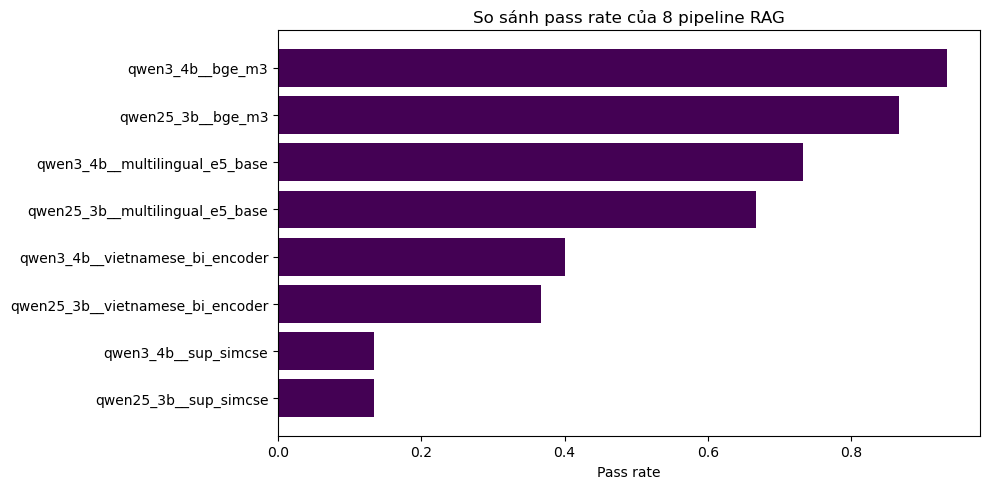

In [10]:
eval_rows = []
for path in sorted(EVAL_DIR.glob("eval_*.json")):
    data = json.loads(path.read_text(encoding="utf-8"))
    summary = data.get("summary", data)
    pipeline = path.stem.replace("eval_", "")
    llm, embedding = pipeline.split("__", 1)
    eval_rows.append({
        "pipeline": pipeline,
        "llm": llm,
        "embedding": embedding,
        "total": summary["total"],
        "passed": summary["passed"],
        "pass_rate": summary["pass_rate"],
        "retrieval_hit_rate": summary["retrieval_hit_rate"],
        "answer_keyword_hit_rate": summary["answer_keyword_hit_rate"],
        "answer_product_name_hit_rate": summary["answer_product_name_hit_rate"],
    })

eval_df = pd.DataFrame(eval_rows).sort_values("pass_rate", ascending=False)
display(eval_df)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = eval_df.sort_values("pass_rate")
ax.barh(plot_df["pipeline"], plot_df["pass_rate"], color="#440154")
ax.set_title("So sánh pass rate của 8 pipeline RAG")
ax.set_xlabel("Pass rate")
plt.tight_layout()
plt.show()

## 2.7. So sánh tốc độ trả lời

Thời gian trả lời được chia thành thời gian truy xuất và thời gian sinh câu trả lời. Kết quả thường cho thấy retrieval rất nhanh, còn generation của LLM chiếm phần lớn thời gian.

,pipeline,so_cau,retrieval_tb_s,generation_tb_s,total_tb_s
2,qwen25_3b__sup_simcse,18,0.020944,10.134378,10.155372
3,qwen25_3b__vietnamese_bi_encoder,18,0.020739,10.659150,10.679967
1,qwen25_3b__multilingual_e5_base,18,0.021822,10.830350,10.852233
0,qwen25_3b__bge_m3,18,0.028067,11.376294,11.404433
7,qwen3_4b__vietnamese_bi_encoder,18,0.027350,16.375328,16.402728
6,qwen3_4b__sup_simcse,18,0.022678,16.388589,16.411322
5,qwen3_4b__multilingual_e5_base,18,0.029594,20.760583,20.790256
4,qwen3_4b__bge_m3,18,0.032067,21.609017,21.641178


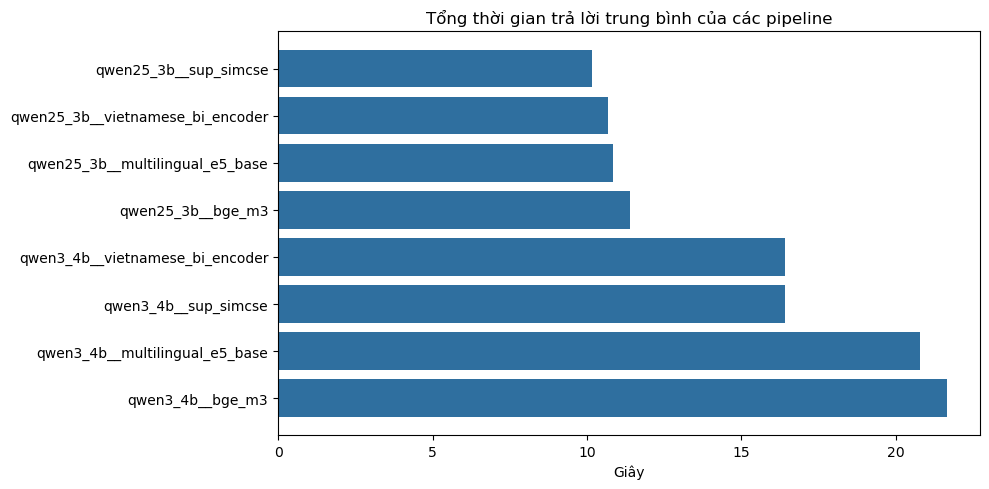

In [11]:
latency_rows = []
for path in sorted(RAG_DIR.glob("*.json")):
    items = json.loads(path.read_text(encoding="utf-8"))
    retrieval_times, generation_times, total_times = [], [], []
    for item in items:
        latency = item.get("latency", {})
        if isinstance(latency.get("retrieval_seconds"), (int, float)):
            retrieval_times.append(latency["retrieval_seconds"])
        if isinstance(latency.get("generation_seconds"), (int, float)):
            generation_times.append(latency["generation_seconds"])
        if isinstance(latency.get("total_seconds"), (int, float)):
            total_times.append(latency["total_seconds"])

    latency_rows.append({
        "pipeline": path.stem,
        "so_cau": len(items),
        "retrieval_tb_s": sum(retrieval_times) / len(retrieval_times) if retrieval_times else None,
        "generation_tb_s": sum(generation_times) / len(generation_times) if generation_times else None,
        "total_tb_s": sum(total_times) / len(total_times) if total_times else None,
    })

latency_df = pd.DataFrame(latency_rows).sort_values("total_tb_s")
display(latency_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(latency_df["pipeline"], latency_df["total_tb_s"], color="#2f6f9f")
ax.set_title("Tổng thời gian trả lời trung bình của các pipeline")
ax.set_xlabel("Giây")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

- Project sử dụng mô hình tiền huấn luyện thay vì huấn luyện từ đầu, phù hợp với hướng transfer learning trong NLP.
- Embedding model đóng vai trò biến văn bản thành vector để truy xuất ngữ nghĩa.
- Qdrant lưu vector và thực hiện tìm kiếm top-k chunks.
- LLM sinh câu trả lời dựa trên context truy xuất được, hạn chế bịa thông tin.
- Redis lưu lịch sử hội thoại ngắn hạn để chatbot hiểu các câu hỏi nối tiếp.
- Kết quả thực nghiệm cho thấy pipeline `qwen3_4b__bge_m3` đạt chất lượng tốt nhất trên bộ `generated_qa_30`, còn `qwen25_3b__bge_m3` cân bằng hơn giữa chất lượng và tốc độ.